In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


In [3]:


base_dir = Path.cwd()
candidate_dirs = [
    base_dir / "../preditcions_screen",  # fallback for typo in folder name
    base_dir / "../predictions_screen",
]

status_dir = next((d.resolve() for d in candidate_dirs if d.exists()), None)
if status_dir is None:
    raise FileNotFoundError(
        f"Could not find screening folder. Checked: {[str(d) for d in candidate_dirs]}"
    )

status_files = sorted(status_dir.glob("status*.csv"))
if not status_files:
    raise FileNotFoundError(f"No files matching 'status*.csv' in {status_dir}")

frames = []
for file_path in status_files:
    df = pd.read_csv(file_path)
    organism = file_path.stem.removeprefix("status_").removeprefix("pred_")
    df["organism"] = organism
    frames.append(df)

status_df = pd.concat(frames, ignore_index=True)
status_df

,query_id,entry_type,annotation_score,status,organism
0,A0A497I8A7,Inactive/Deleted,0.0,Inactive,DPANN
1,A0A497TBJ4,Inactive/Deleted,0.0,Inactive,DPANN
2,A0A497TGJ1,Inactive/Deleted,0.0,Inactive,DPANN
3,A0A662QS27,Inactive/Deleted,0.0,Inactive,DPANN
4,A0A7J3XEB6,Inactive/Deleted,0.0,Inactive,DPANN
...,...,...,...,...,...
411152,A0A5P8K6Y5,UniProtKB/TrEMBL,1.0,Active,strep
411153,A0A5P2CQX7,UniProtKB/TrEMBL,1.0,Active,strep
411154,V6JE57,Inactive/Deleted,0.0,Inactive,strep
411155,A0A0L8LR84,UniProtKB/TrEMBL,1.0,Active,strep


In [4]:

def add_cosmetics(title='', 
                  xlabel='', ylabel='',ax=None,grid=False,my_col ='0.2'):
    plt.title(title, fontsize=30,fontname='Arial', weight='bold', color=my_col)
    plt.xlabel(xlabel, fontsize=30,fontname='Arial', weight='bold', color=my_col)
    plt.ylabel(ylabel, fontsize=30,fontname='Arial', weight='bold', color=my_col)
    plt.xticks(fontsize=25,fontname='Arial', weight='bold', color=my_col)
    plt.yticks(fontsize=25,fontname='Arial', weight='bold', color=my_col)
    if grid:    
        plt.grid(color='black',axis='both',linestyle=':',linewidth=0.5,which='major')


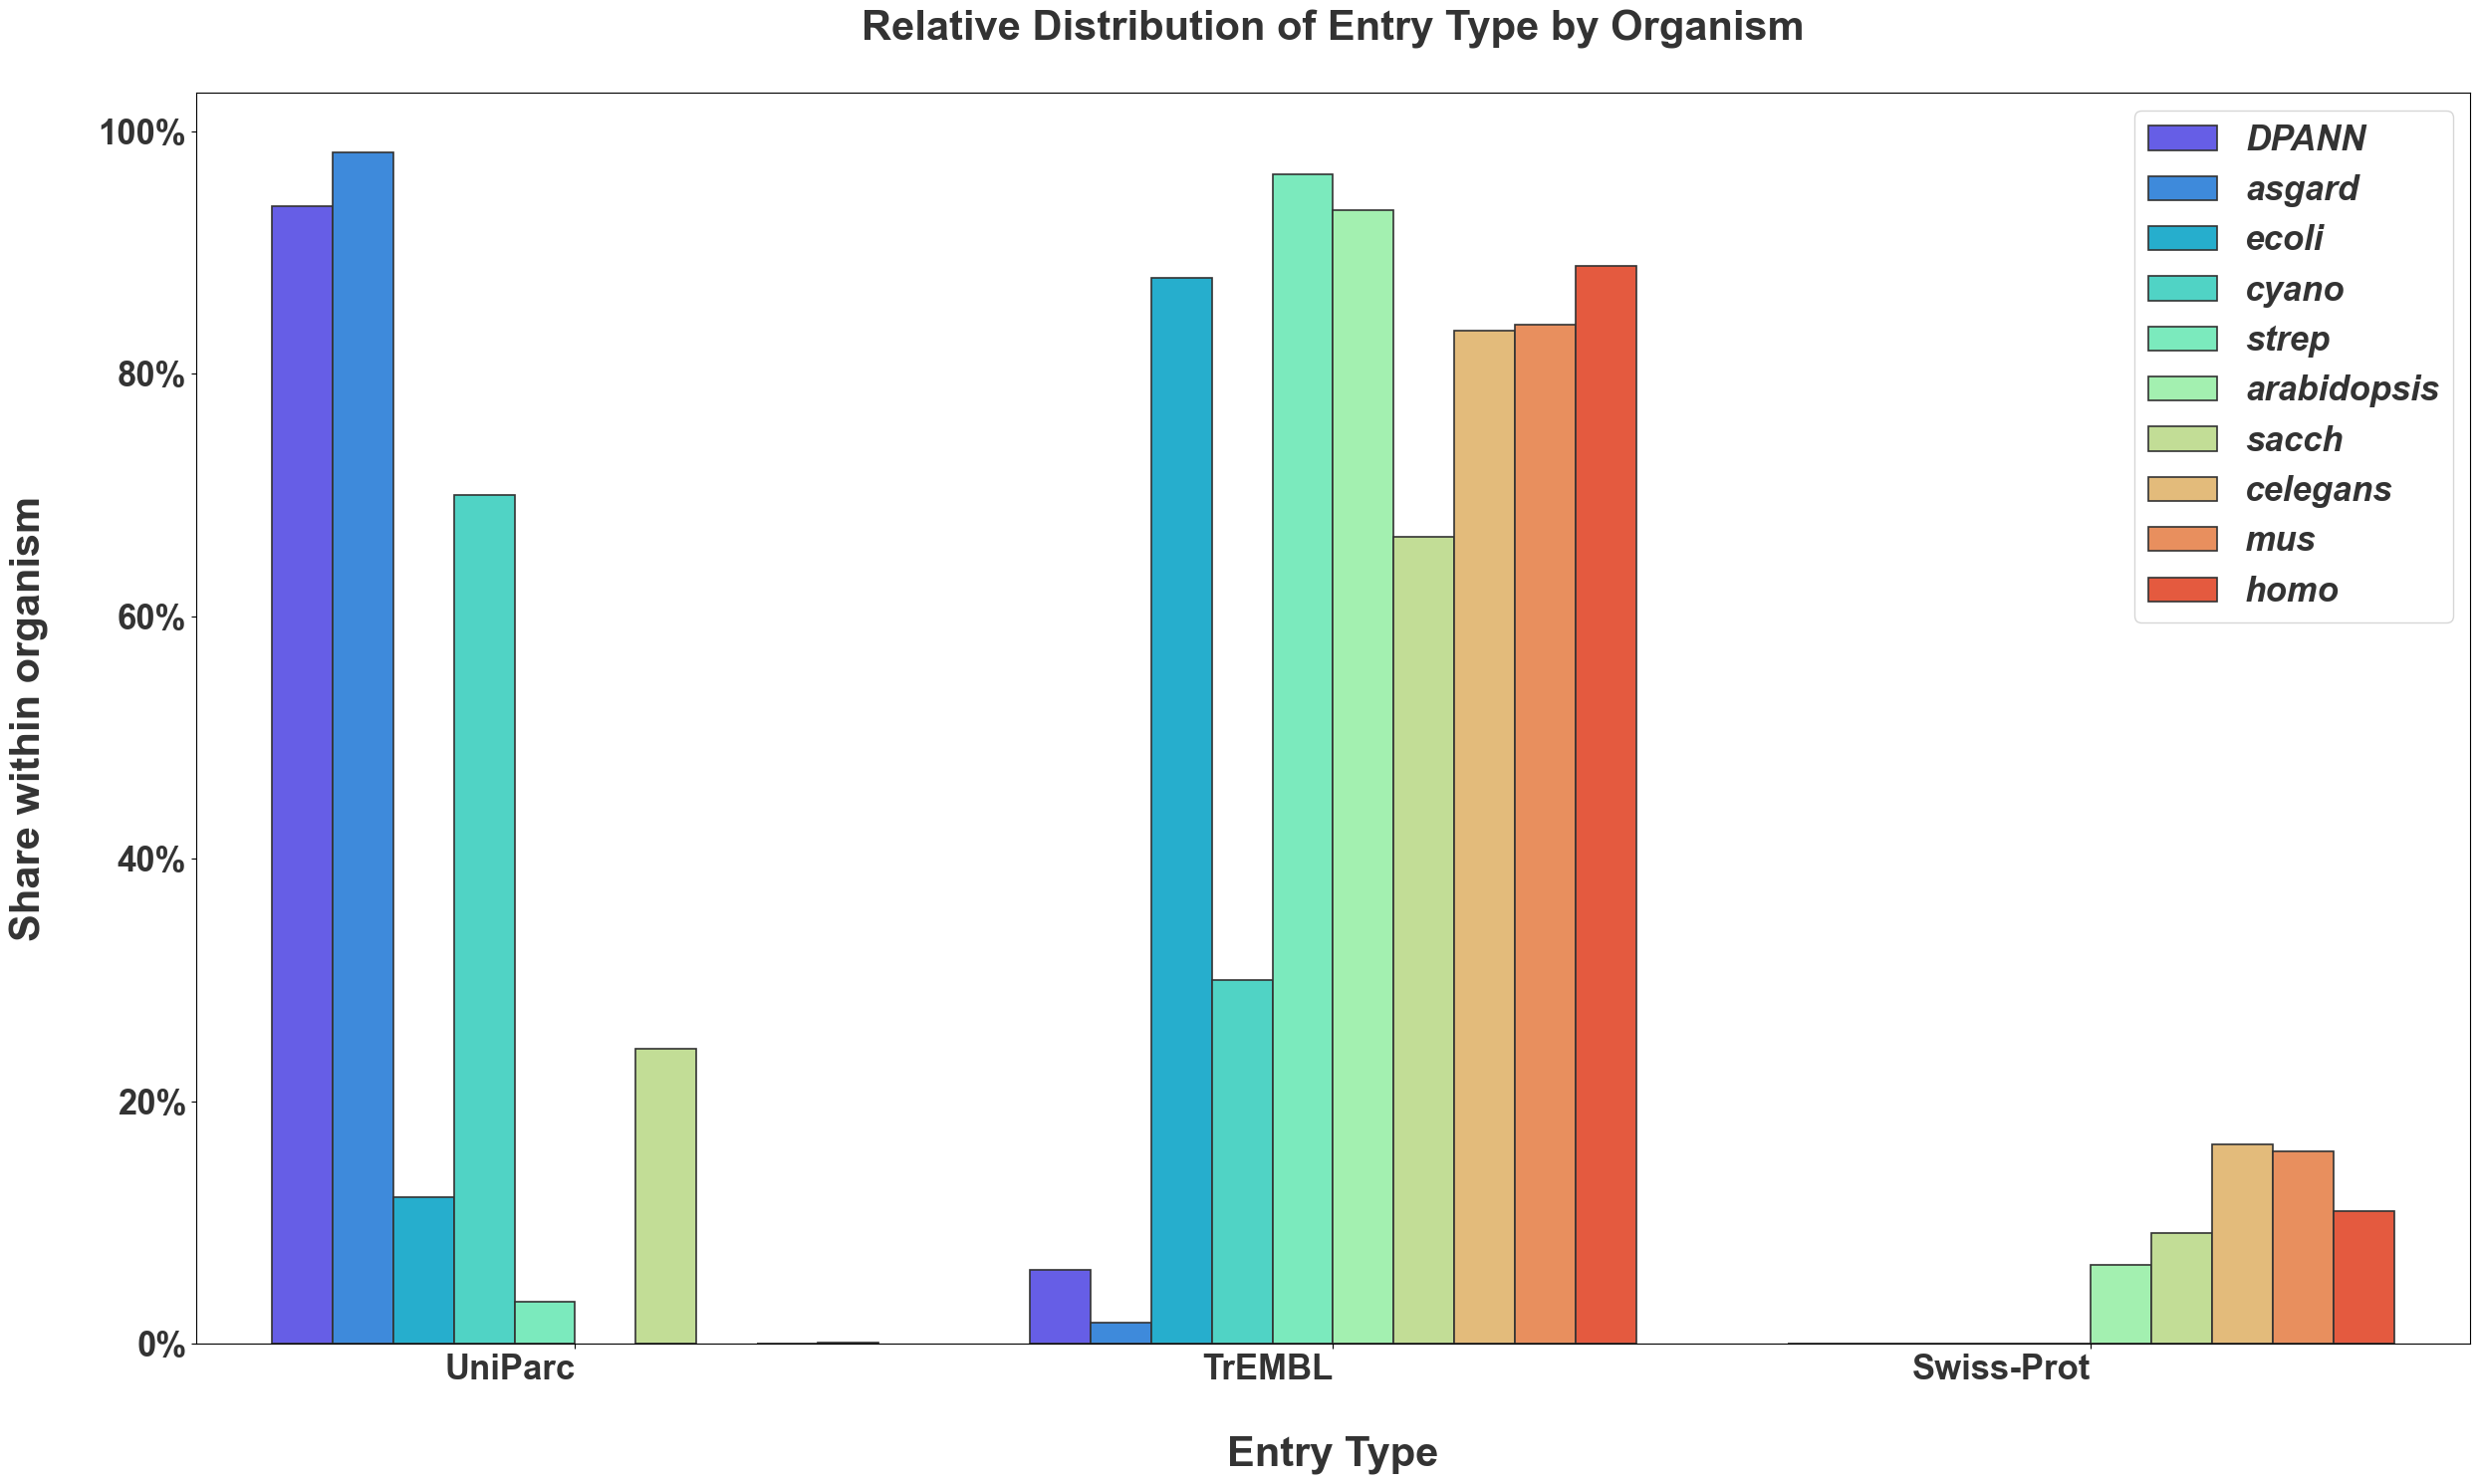

In [8]:
entry_col = "entry_type" if "entry_type" in status_df.columns else "entrytype"

desired_order = ["DPANN", "asgard", "ecoli", "cyano", "strep", "arabidopsis", "sacch", "celegans", "mus", "homo"]

plot_df = (
    status_df.groupby([entry_col, "organism"]).size().rename("count").reset_index()
)
plot_df["fraction"] = plot_df["count"] / plot_df.groupby("organism")["count"].transform("sum")
plot_df["organism"] = pd.Categorical(plot_df["organism"], categories=desired_order, ordered=True)
plot_df = plot_df.sort_values("organism")

plt.figure(figsize=(25, 15))
sns.barplot(
    data=plot_df,
    x=entry_col,
    y="fraction",
    hue="organism",
    hue_order=desired_order,
    palette="rainbow",
    edgecolor="0.2",
    linewidth=1.2,
    errorbar=None,
 )
plt.title("Relative Distribution of Entry Type by Organism")
plt.xlabel("Entry Type")
plt.ylabel("Share within organism")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(ticks=[0, 1, 2],    labels=['UniParc', 'TrEMBL', 'Swiss-Prot'],ha="right")
# plt.xtick_labels(['UniParc','TrEMBL','Swiss-Prot'], rotation=25, ha="right", fontsize=25, fontname='Arial', weight='bold', color='0.2')
plt.legend(title="Organism", bbox_to_anchor=(1.02, 1), loc="upper left")
add_cosmetics(title='Relative Distribution of Entry Type by Organism\n',xlabel='\nEntry Type',ylabel='Share within organism\n')

plt.rc('font',family='Arial',weight='bold')
plt.rc('legend')
handles, labels = plt.gca().get_legend_handles_labels()

order = [0,1,2,3,4,5,6,7,8,9]
l = plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc=1, prop={'size': 25})

for text in l.get_texts():
    text.set_color("0.2")
    text.set_style('italic')
    
for leg in l.legend_handles:
    leg.set_alpha(1)
plt.tight_layout()
plt.show()

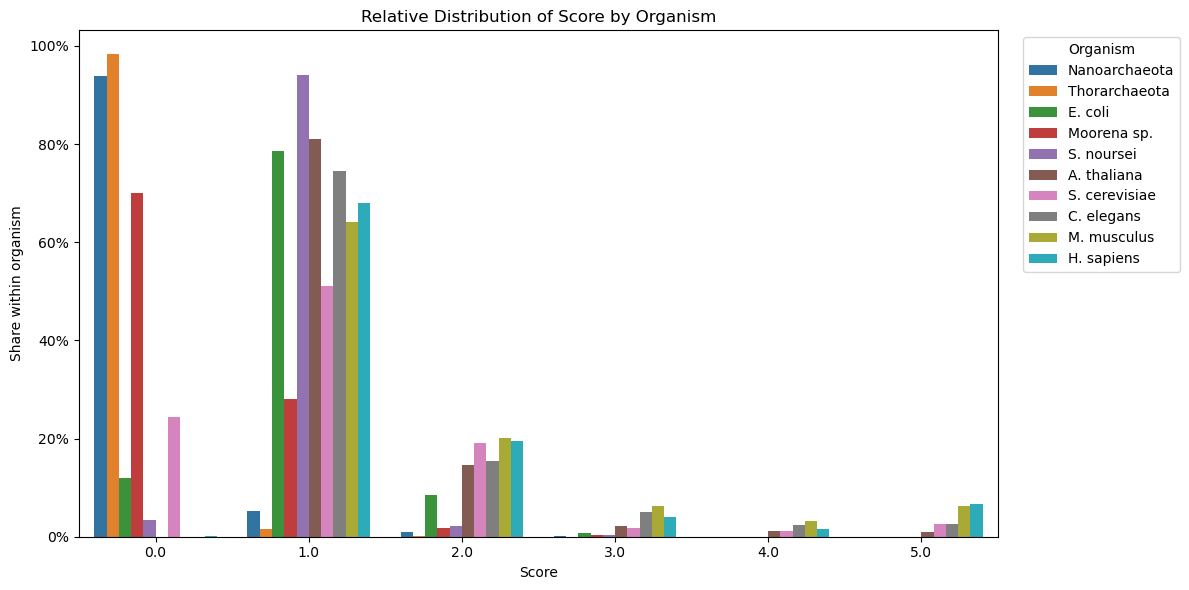

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

score_col = "annotation_score" if "annotation_score" in status_df.columns else "score"

score_plot_df = (
    status_df.assign(
        organism=status_df["organism"].map(organism_name_map).fillna(status_df["organism"])
    )
    .groupby([score_col, "organism"]).size().rename("count").reset_index()
)
score_plot_df["fraction"] = score_plot_df["count"] / score_plot_df.groupby("organism")["count"].transform("sum")
score_plot_df["organism"] = pd.Categorical(
    score_plot_df["organism"], categories=desired_order, ordered=True
)
score_plot_df = score_plot_df.sort_values(["organism", score_col])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=score_plot_df,
    x=score_col,
    y="fraction",
    hue="organism",
    hue_order=desired_order,
)
plt.title("Relative Distribution of Score by Organism")
plt.xlabel("Score")
plt.ylabel("Share within organism")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(title="Organism", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()